In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../datasets/mads_synthetic_dataset_3.csv")
df.head()

,event_id,timestamp,machine,event_type,feature_1,feature_2,feature_3,feature_4,feature_5,ip_address,user_id,process,label
0,EVT-00001,2025-04-13 12:00:00.000000,machine1,execution_suspicious_process,0.6089,0.4587,1.0347,0.7039,0.6019,192.168.1.75,U1017,netstat.exe,malicious
1,EVT-00002,2025-04-13 12:01:01.563700,machine1,lateral_movement,0.1973,1.0347,1.0673,0.1014,0.7431,192.168.1.125,U1008,msiexec.exe,malicious
2,EVT-00003,2025-04-13 12:02:13.269421,machine1,normal_activity,0.4294,0.6387,0.7711,0.5158,0.6117,192.168.1.25,U1017,msiexec.exe,benign
3,EVT-00004,2025-04-13 12:02:47.705168,machine1,phishing_credential_stealer,0.7158,0.9808,1.1189,0.8179,0.6464,192.168.1.65,U1009,whoami.exe,malicious
4,EVT-00005,2025-04-13 12:03:23.701545,machine1,normal_activity,-0.0396,0.3416,0.9948,0.5987,0.8392,192.168.1.55,U1008,msiexec.exe,benign


In [3]:
from sklearn.model_selection import train_test_split

In [5]:

# Same split as the model notebook: 70/30, stratified, random_state=42
# Splitting on the full df so all columns are preserved in the test set
_, df_test = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['label']
)

df_test = df_test.reset_index(drop=True)
print(f"Test samples: {len(df_test)}")
df_test.head()


Test samples: 3000


,event_id,timestamp,machine,event_type,feature_1,feature_2,feature_3,feature_4,feature_5,ip_address,user_id,process,label
0,EVT-06350,2025-04-17 20:29:25.746775,machine4,data_exfiltration,0.0958,0.6155,1.0390,1.2843,1.0098,192.168.1.95,U1005,powershell.exe,malicious
1,EVT-05775,2025-04-17 10:50:46.676781,machine3,c2_connection,0.8194,1.5875,0.9584,0.9116,0.3486,192.168.1.75,U1013,powershell.exe,malicious
2,EVT-04704,2025-04-16 17:25:20.347832,machine2,failed_login_attempts,0.8414,0.3033,0.8260,1.1033,1.2761,192.168.1.65,U1004,netstat.exe,malicious
3,EVT-07436,2025-04-18 14:20:35.552984,machine4,normal_activity,0.6063,0.3875,0.3642,0.3051,0.4078,192.168.1.130,U1003,nc.exe,benign
4,EVT-08523,2025-04-19 08:29:12.440228,machine4,data_exfiltration,0.2025,0.4765,0.1922,0.6753,0.4644,192.168.1.40,U1010,powershell.exe,malicious


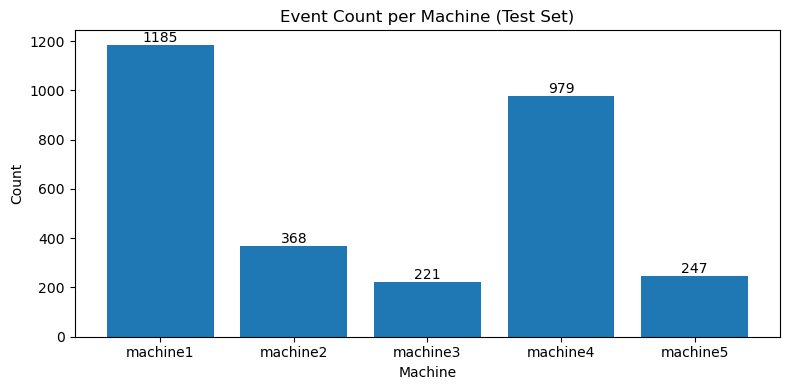

In [6]:

import matplotlib.pyplot as plt

machine_counts = df_test['machine'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(machine_counts.index, machine_counts.values)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(int(bar.get_height())),
        ha='center', va='bottom'
    )

ax.set_xlabel("Machine")
ax.set_ylabel("Count")
ax.set_title("Event Count per Machine (Test Set)")
plt.tight_layout()
plt.show()


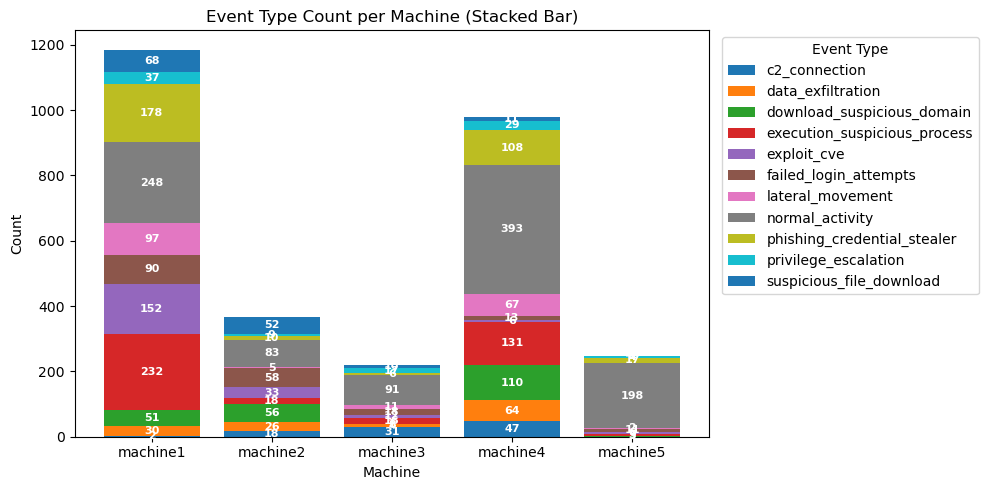

In [7]:

# Stacked bar chart — event_type count per machine, coloured by event_type
pivot = df_test.groupby(['machine', 'event_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
bottom = None
for event_type in pivot.columns:
    bars = ax.bar(pivot.index, pivot[event_type], label=event_type, bottom=bottom)
    for bar, b in zip(bars, (bottom if bottom is not None else [0] * len(pivot))):
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                b + height / 2,
                str(int(height)),
                ha='center', va='center', fontsize=8, color='white', fontweight='bold'
            )
    bottom = pivot[event_type].values if bottom is None else bottom + pivot[event_type].values

ax.set_xlabel("Machine")
ax.set_ylabel("Count")
ax.set_title("Event Type Count per Machine (Stacked Bar)")
ax.legend(title="Event Type", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


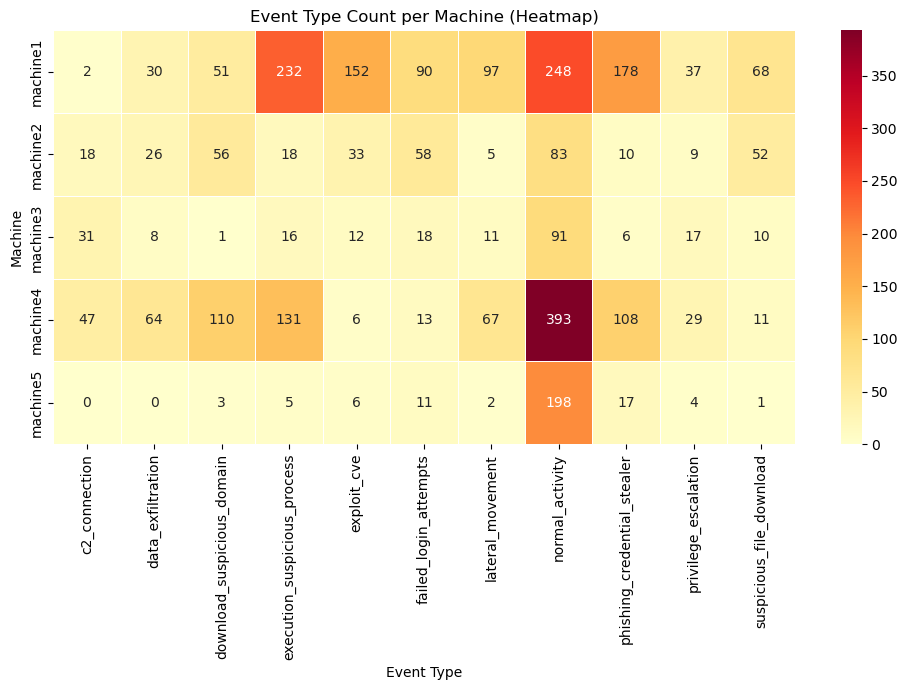

In [8]:

import seaborn as sns

# Heatmap — event_type count per machine
pivot_heat = df_test.groupby(['machine', 'event_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot_heat, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_xlabel("Event Type")
ax.set_ylabel("Machine")
ax.set_title("Event Type Count per Machine (Heatmap)")
plt.tight_layout()
plt.show()


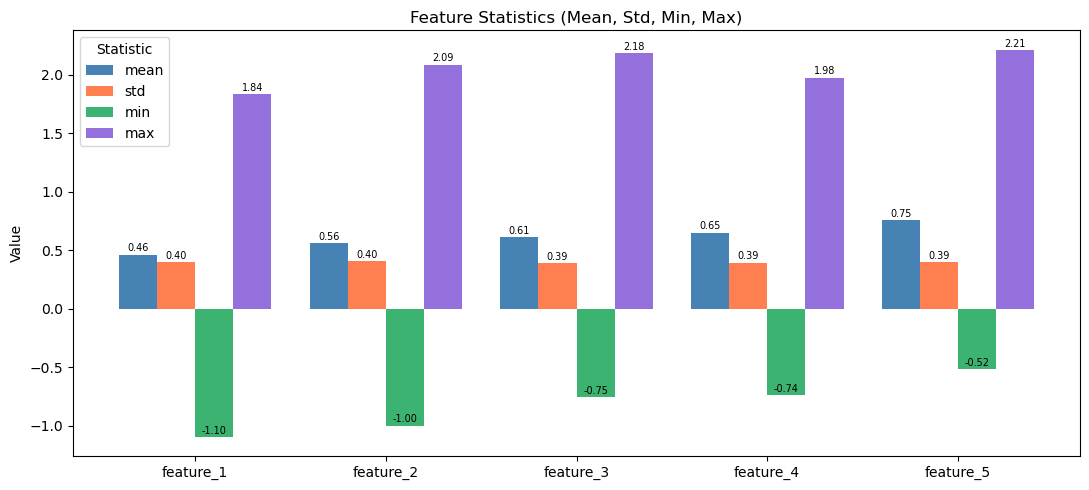

In [9]:

feature_cols = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
stats = df_test[feature_cols].agg(['mean', 'std', 'min', 'max'])

x = range(len(feature_cols))
stat_labels = ['mean', 'std', 'min', 'max']
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
width = 0.2

fig, ax = plt.subplots(figsize=(11, 5))
for i, (stat, color) in enumerate(zip(stat_labels, colors)):
    offsets = [xi + i * width for xi in x]
    bars = ax.bar(offsets, stats.loc[stat], width=width, label=stat, color=color)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.2f}",
            ha='center', va='bottom', fontsize=7
        )

ax.set_xticks([xi + 1.5 * width for xi in x])
ax.set_xticklabels(feature_cols)
ax.set_ylabel("Value")
ax.set_title("Feature Statistics (Mean, Std, Min, Max)")
ax.legend(title="Statistic")
plt.tight_layout()
plt.show()


# MADS Algorithm

Implementation of **Algorithm 1** from the MADS paper.

Each machine maintains its own:
- **AlertList** — a sliding window buffer of recent events
- **MaliciousSamples** counter — high-confidence NN-label disagreements in the current window
- **IncidentList** — confirmed incidents flushed when the counter hits `IncidentThreshold`

Detection uses a **k-NN vote** inside the window: an event increments the counter when the neighbourhood majority label disagrees with the NN-assigned label **and** the vote confidence exceeds **0.60**.


In [10]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from sklearn.neighbors import NearestNeighbors


In [11]:
# ── Load the saved NN model ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root → finds threat_classifier.py

from threat_classifier import ThreatClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split as _tts

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ThreatClassifier(input_dim=5)
model.load_state_dict(
    torch.load("../models/saved_models/threat_classifier_nn.pth", map_location=device)
)
model.to(device)
model.eval()   # disable Dropout for inference

# ── Rebuild the scaler (no new NN training) ───────────────────────────────────
# StandardScaler is deterministic: same split parameters → same mean/std as training.
_feature_cols = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
_df_full      = pd.read_csv("../datasets/mads_synthetic_dataset.csv")
_X_all        = _df_full[_feature_cols].values.astype(np.float32)
_y_all        = (_df_full['label'] == 'malicious').astype(np.float32).values

_X_train, _, _, _ = _tts(_X_all, _y_all, test_size=0.3, random_state=42, stratify=_y_all)

scaler = StandardScaler()
scaler.fit(_X_train)

print(f"Model loaded  ({device})")
print(f"Scaler mean:  {scaler.mean_.round(4)}")
print(f"Scaler std :  {scaler.scale_.round(4)}")


Model loaded  (cpu)
Scaler mean:  [0.4602 0.5596 0.6227 0.6572 0.7431]
Scaler std :  [0.3999 0.4014 0.3988 0.3972 0.4047]


In [12]:
# ── Assign NN labels to every event in the test set ──────────────────────────
# The NN operates on the same five features used during training.
# Raw features → StandardScaler → NN logit → sigmoid → binary label

feature_cols = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']

# Scale raw features with the training-set scaler (identical to training pipeline)
X_raw    = df_test[feature_cols].values.astype(np.float32)
X_scaled = scaler.transform(X_raw).astype(np.float32)

# Run all events through the model in one batch (no_grad for inference)
with torch.no_grad():
    logits      = model(torch.from_numpy(X_scaled).to(device))
    probs       = torch.sigmoid(logits).cpu().numpy()          # (n,) probabilities
    nn_labels   = (probs >= 0.5).astype(int)                   # 1 = malicious, 0 = benign

# Attach NN outputs back to df_test for easy per-event access
df_test = df_test.copy()
df_test['nn_label']      = nn_labels          # NN prediction (int: 0/1)
df_test['nn_prob']       = probs.round(4)     # NN confidence score
df_test['X_scaled']      = list(X_scaled)     # scaled feature vector (for k-NN distances)

label_map = {0: 'benign', 1: 'malicious'}
df_test['nn_label_str'] = df_test['nn_label'].map(label_map)

print(f"Events in test set : {len(df_test)}")
print(f"NN → benign        : {(nn_labels == 0).sum()}")
print(f"NN → malicious     : {(nn_labels == 1).sum()}")
df_test[['machine', 'event_type', 'label', 'nn_label_str', 'nn_prob']].head(8)


Events in test set : 3000
NN → benign        : 881
NN → malicious     : 2119


,machine,event_type,label,nn_label_str,nn_prob
0,machine4,data_exfiltration,malicious,malicious,0.9641
1,machine3,c2_connection,malicious,malicious,0.9940
2,machine2,failed_login_attempts,malicious,malicious,0.9814
3,machine4,normal_activity,benign,benign,0.3254
4,machine4,data_exfiltration,malicious,benign,0.2915
5,machine1,failed_login_attempts,malicious,malicious,0.9335
6,machine2,download_suspicious_domain,malicious,malicious,0.5662
7,machine5,normal_activity,benign,benign,0.1859


In [13]:
df_test.head()

,event_id,timestamp,machine,event_type,feature_1,feature_2,feature_3,feature_4,feature_5,ip_address,user_id,process,label,nn_label,nn_prob,X_scaled,nn_label_str
0,EVT-06350,2025-04-17 20:29:25.746775,machine4,data_exfiltration,0.0958,0.6155,1.0390,1.2843,1.0098,192.168.1.95,U1005,powershell.exe,malicious,1,0.9641,"[-0.911307, 0.13928358, 1.0439734, 1.5788574, ...",malicious
1,EVT-05775,2025-04-17 10:50:46.676781,machine3,c2_connection,0.8194,1.5875,0.9584,0.9116,0.3486,192.168.1.75,U1013,powershell.exe,malicious,1,0.9940,"[0.89831644, 2.5607653, 0.84184957, 0.6405518,...",malicious
2,EVT-04704,2025-04-16 17:25:20.347832,machine2,failed_login_attempts,0.8414,0.3033,0.8260,1.1033,1.2761,192.168.1.65,U1004,netstat.exe,malicious,1,0.9814,"[0.9533354, -0.6384803, 0.5098247, 1.1231737, ...",malicious
3,EVT-07436,2025-04-18 14:20:35.552984,machine4,normal_activity,0.6063,0.3875,0.3642,0.3051,0.4078,192.168.1.130,U1003,nc.exe,benign,0,0.3254,"[0.36538282, -0.42871824, -0.6482496, -0.88636...",benign
4,EVT-08523,2025-04-19 08:29:12.440228,machine4,data_exfiltration,0.2025,0.4765,0.1922,0.6753,0.4644,192.168.1.40,U1010,powershell.exe,malicious,0,0.2915,"[-0.644465, -0.20699817, -1.0795809, 0.0456454...",benign


In [23]:
# ── detectMaliciousSamples (Algorithm 1, lines 19-29) ────────────────────────
#
# For each event in the AlertList:
#   1. Find its k nearest neighbours within the AlertList (by Euclidean distance
#      in scaled feature space), excluding the event itself.
#   2. Majority-vote those neighbours to get a 'voted label'.
#   3. Compute vote confidence = count(majority) / k.
#   4. If confidence > 0.60  AND  voted label ≠ event's NN label → increment.
#
# Returns the total number of such "disagreement" events.

CONFIDENCE_THRESHOLD = 0.60


def detect_malicious_samples(alert_list: list, k: int) -> int:
    """
    Parameters
    ----------
    alert_list : list of dicts
        Each dict must contain 'nn_label' (int 0/1) and 'X_scaled' (np.ndarray).
    k : int
        Neighbourhood size.  Neighbours are drawn from the AlertList itself.

    Returns
    -------
    int  — number of events whose neighbourhood majority disagrees with nn_label
           at > CONFIDENCE_THRESHOLD confidence.
    """
    n = len(alert_list)

    # Build feature matrix for the current window
    X_window = np.array([e['X_scaled'] for e in alert_list])   # shape (n, 5)

    # k+1 because the query point itself is always the nearest neighbour (dist=0)
    n_neighbors = min(k + 1, n)
    knn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    knn.fit(X_window)

    _, indices = knn.kneighbors(X_window)   # indices shape: (n, n_neighbors)

    malicious_count = 0
    for i, event in enumerate(alert_list):
        # Exclude the event itself (index i) from its own neighbourhood
        neighbour_indices = [idx for idx in indices[i] if idx != i][:k]

        if not neighbour_indices:
            continue

        # Majority vote on NN labels of neighbours
        neighbour_labels = [alert_list[j]['nn_label'] for j in neighbour_indices]
        vote       = int(np.round(np.mean(neighbour_labels)))   # 0 or 1
        confidence = neighbour_labels.count(vote) / len(neighbour_labels)

        # Disagreement: neighbours vote differently from the event's NN label
        # if confidence > CONFIDENCE_THRESHOLD and vote != event['nn_label']:
        if confidence > CONFIDENCE_THRESHOLD and vote == 1:   # vote = 1 means majority says "malicious"
            malicious_count += 1

    return malicious_count


print(f"detect_malicious_samples defined  (confidence threshold = {CONFIDENCE_THRESHOLD})")


detect_malicious_samples defined  (confidence threshold = 0.6)


In [24]:
# ── createIncident (Algorithm 1, line 30) ────────────────────────────────────
#
# Packages the current AlertList into a structured incident record that captures:
#   - incidentID and originating machine (for traceability)
#   - time range (first_seen / last_seen) of the window's events
#   - full list of events in the flush window
#   - breakdown of NN-predicted labels in the window

def create_incident(alert_list: list, incident_id: int) -> dict:
    """
    Parameters
    ----------
    alert_list : list of dicts  — events in the current window
    incident_id : int

    Returns
    -------
    dict  — incident record
    """
    timestamps = [e['timestamp'] for e in alert_list]
    nn_labels  = [e['nn_label'] for e in alert_list]

    return {
        'incident_id'       : incident_id,
        'machine'           : alert_list[0]['machine'],
        'first_seen'        : min(timestamps),
        'last_seen'         : max(timestamps),
        'event_count'       : len(alert_list),
        'malicious_in_window': sum(nn_labels),
        'benign_in_window'  : len(nn_labels) - sum(nn_labels),
        'events'            : [e['event_id'] for e in alert_list],
    }


print("create_incident defined")


create_incident defined


In [25]:
# ── MADS main loop (Algorithm 1, lines 1-18) ─────────────────────────────────
#
# The algorithm is applied independently to each machine's event stream.
# Events are sorted by timestamp to respect the temporal order of the stream.
#
# Parameters
# ──────────
# K                 : sliding window size (minimum events before detection runs)
# INCIDENT_THRESHOLD: how many disagreement events trigger a formal incident

K                  = 5
INCIDENT_THRESHOLD = 3

all_incidents = {}   # machine → list of incident dicts

for machine, machine_df in df_test.groupby('machine'):

    # Sort events chronologically to simulate the arriving stream
    stream = machine_df.sort_values('timestamp').to_dict(orient='records')

    # ── Per-machine state (Algorithm 1, line 1) ───────────────────────────────
    alert_list       = []
    incident_list    = []
    malicious_samples = 0
    incident_id       = 1

    # ── Stream ingestion (Algorithm 1, lines 2-17) ───────────────────────────
    for event in stream:

        # Line 3: append every incoming event to the AlertList
        alert_list.append(event)

        # Line 4: detection only fires once we have at least k events
        if len(alert_list) >= K:

            # Line 5-6: count disagreement events in the current window
            new_malicious    = detect_malicious_samples(alert_list, K)
            malicious_samples += new_malicious

            # Line 7: have we crossed the incident threshold?
            if malicious_samples >= INCIDENT_THRESHOLD:

                # Lines 8-10: log the incident
                incident = create_incident(alert_list, incident_id)
                incident_list.append(incident)
                incident_id += 1

                # Lines 11-12: reset counter and flush the window
                malicious_samples = 0
                alert_list.clear()

            else:
                # Line 14: slide the window — drop the oldest event
                alert_list.pop(0)

    all_incidents[machine] = incident_list
    print(f"{machine:10s}  events={len(stream):3d}  incidents={len(incident_list)}")

print(f"\nTotal incidents across all machines: {sum(len(v) for v in all_incidents.values())}")


machine1    events=1185  incidents=213
machine2    events=368  incidents=65
machine3    events=221  incidents=35
machine4    events=979  incidents=149
machine5    events=247  incidents=27

Total incidents across all machines: 489


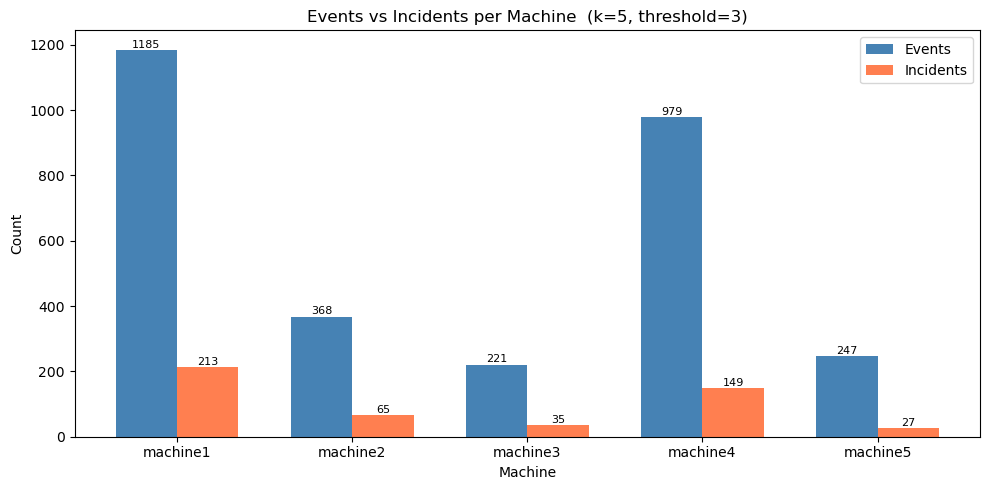

In [28]:

# ── Events vs Incidents per Machine ──────────────────────────────────────────

machines       = sorted(df_test['machine'].unique())
event_counts   = [len(df_test[df_test['machine'] == m]) for m in machines]
incident_counts = [len(all_incidents.get(m, [])) for m in machines]

x     = range(len(machines))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_e = ax.bar([xi - width / 2 for xi in x], event_counts,   width, label='Events',    color='steelblue')
bars_i = ax.bar([xi + width / 2 for xi in x], incident_counts, width, label='Incidents', color='coral')

for bar in bars_e:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
for bar in bars_i:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(machines)
ax.set_xlabel("Machine")
ax.set_ylabel("Count")
ax.set_title(f"Events vs Incidents per Machine  (k={K}, threshold={INCIDENT_THRESHOLD})")
ax.legend()
plt.tight_layout()
plt.show()


In [26]:
# ── Display results ───────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

rows = []
for machine, incidents in all_incidents.items():
    for inc in incidents:
        rows.append({
            'Incident ID'   : inc['incident_id'],
            'Machine'       : inc['machine'],
            'First Seen'    : inc['first_seen'],
            'Last Seen'     : inc['last_seen'],
            'Events in Window': inc['event_count'],
            'NN Malicious'  : inc['malicious_in_window'],
            'NN Benign'     : inc['benign_in_window'],
            'Event IDs'     : ', '.join(inc['events']),
        })

if rows:
    df_incidents = pd.DataFrame(rows)
    print(f"Incidents raised (k={K}, threshold={INCIDENT_THRESHOLD}):\n")
    display(df_incidents)
else:
    print(f"No incidents raised with k={K}, threshold={INCIDENT_THRESHOLD}.")
    print("Try lowering INCIDENT_THRESHOLD or K in the previous cell.")


Incidents raised (k=5, threshold=3):



,Incident ID,Machine,First Seen,Last Seen,Events in Window,NN Malicious,NN Benign,Event IDs
0,1,machine1,2025-04-13 12:02:47.705168,2025-04-13 12:21:00.540521,5,4,1,"EVT-00004, EVT-00005, EVT-00010, EVT-00019, EV..."
1,2,machine1,2025-04-13 12:21:02.843295,2025-04-13 12:46:31.666663,5,4,1,"EVT-00022, EVT-00026, EVT-00033, EVT-00034, EV..."
2,3,machine1,2025-04-13 13:03:01.411614,2025-04-13 13:24:12.086438,5,3,2,"EVT-00055, EVT-00061, EVT-00064, EVT-00065, EV..."
3,4,machine1,2025-04-13 13:26:22.310782,2025-04-13 13:47:44.219741,5,4,1,"EVT-00075, EVT-00082, EVT-00086, EVT-00087, EV..."
4,5,machine1,2025-04-13 13:51:51.251706,2025-04-13 13:59:22.001526,5,5,0,"EVT-00101, EVT-00102, EVT-00104, EVT-00105, EV..."
...,...,...,...,...,...,...,...,...
484,23,machine5,2025-04-20 05:53:20.244434,2025-04-20 06:06:44.538530,5,3,2,"EVT-09805, EVT-09810, EVT-09812, EVT-09814, EV..."
485,24,machine5,2025-04-20 06:13:01.199989,2025-04-20 06:20:48.723132,5,4,1,"EVT-09822, EVT-09824, EVT-09827, EVT-09831, EV..."
486,25,machine5,2025-04-20 07:26:21.588993,2025-04-20 07:30:49.863337,5,3,2,"EVT-09893, EVT-09895, EVT-09896, EVT-09897, EV..."
487,26,machine5,2025-04-20 07:56:36.984511,2025-04-20 08:06:57.679473,5,3,2,"EVT-09918, EVT-09922, EVT-09924, EVT-09927, EV..."


In [27]:
df_incidents[df_incidents['NN Benign'] >= 2]

,Incident ID,Machine,First Seen,Last Seen,Events in Window,NN Malicious,NN Benign,Event IDs
2,3,machine1,2025-04-13 13:03:01.411614,2025-04-13 13:24:12.086438,5,3,2,"EVT-00055, EVT-00061, EVT-00064, EVT-00065, EV..."
11,12,machine1,2025-04-13 15:59:20.927961,2025-04-13 16:09:51.939237,5,3,2,"EVT-00227, EVT-00231, EVT-00232, EVT-00236, EV..."
22,23,machine1,2025-04-13 19:37:52.163564,2025-04-13 19:55:26.776744,5,3,2,"EVT-00432, EVT-00441, EVT-00444, EVT-00445, EV..."
29,30,machine1,2025-04-13 22:18:41.894456,2025-04-13 22:36:03.146898,5,3,2,"EVT-00582, EVT-00588, EVT-00589, EVT-00598, EV..."
37,38,machine1,2025-04-14 00:28:49.121773,2025-04-14 00:50:56.522964,5,3,2,"EVT-00723, EVT-00726, EVT-00731, EVT-00739, EV..."
...,...,...,...,...,...,...,...,...
483,22,machine5,2025-04-20 05:14:14.165184,2025-04-20 05:20:26.452144,5,3,2,"EVT-09762, EVT-09763, EVT-09765, EVT-09771, EV..."
484,23,machine5,2025-04-20 05:53:20.244434,2025-04-20 06:06:44.538530,5,3,2,"EVT-09805, EVT-09810, EVT-09812, EVT-09814, EV..."
486,25,machine5,2025-04-20 07:26:21.588993,2025-04-20 07:30:49.863337,5,3,2,"EVT-09893, EVT-09895, EVT-09896, EVT-09897, EV..."
487,26,machine5,2025-04-20 07:56:36.984511,2025-04-20 08:06:57.679473,5,3,2,"EVT-09918, EVT-09922, EVT-09924, EVT-09927, EV..."
